# Section 1: Market and Demand Sizing

## Purpose of This Section
This notebook establishes the market foundation for the techno-economic concept. It addresses three fundamental requirements:
1. Validating the demand for a 10-20 MW data center in Africa, specifically Nigeria.
2. Quantifying the scale and growth rate of the opportunity.
3. Defining the target customer load profile for subsequent engineering and financial modeling.

## Key Sources and References
* **Africa Data Centres Association (ADCA)**: Continental capacity estimates (2025). [africadatacentres.org](https://africadatacentres.org/)
* **Xalam Analytics**: Africa data center market sizing and projections (2025). [xalamanalytics.com](https://xalamanalytics.com/)
* **IFC**: Digital Infrastructure in Africa (2023). [ifc.org](https://www.ifc.org/en/what-we-do/sector-expertise/telecom-media-technology)
* **TeleGeography**: Submarine Cable Map (2026). [submarinecablemap.com](https://www.submarinecablemap.com/)
* **GSMA**: Mobile Economy Sub-Saharan Africa (2024). [gsma.com](https://www.gsma.com/mobileeconomy/sub-saharan-africa/)


In [1]:
!pip install folium


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import json
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

COLORS = {
    'primary': '#1B4332',
    'secondary': '#2D6A4F',
    'accent': '#40916C',
    'highlight': '#F77F00',
    'warning': '#D62828',
    'neutral': '#6C757D',
    'light': '#95D5B2',
    'bg': '#F8F9FA',
    'text': '#212529',
}
PALETTE = [COLORS['primary'], COLORS['highlight'], COLORS['accent'],
           COLORS['secondary'], COLORS['warning'], COLORS['light']]
sns.set_palette(PALETTE)

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../data', exist_ok=True)


## 1.1 The Macro Opportunity

Africa's data center market is undergoing structural expansion driven by several factors:
1. **Internet Penetration**: Africa has approximately 570M internet users (36% penetration), projected to double by 2030 (GSMA).
2. **Mobile Data Consumption**: Average mobile data per user grew from 2.3 GB/month in 2019 to 7.5 GB/month in 2024.
3. **Hyperscaler Entry**: AWS, Microsoft Azure, and Google Cloud have established or are establishing local regions.
4. **Data Sovereignty Regulations**: New privacy acts in Nigeria, Kenya, and South Africa encourage localized data hosting.
5. **AI Compute Demand**: Generative AI inference workloads require low-latency, localized compute capabilities.


In [3]:
africa_dc_capacity = pd.DataFrame({
    'Year': [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030],
    'Operational_MW': [120, 155, 210, 280, 370, 450, 520, 600, 720, 880, 1100, 1400],
    'Type': ['Actual']*7 + ['Current'] + ['Projected']*4
})

africa_dc_capacity['YoY_Growth'] = africa_dc_capacity['Operational_MW'].pct_change() * 100
cagr_2019_2030 = ((1400 / 120) ** (1/11) - 1) * 100

print(f"2019-2030 CAGR: {cagr_2019_2030:.1f}%")
print(f"2026 Operational Capacity: ~600 MW")


2019-2030 CAGR: 25.0%
2026 Operational Capacity: ~600 MW


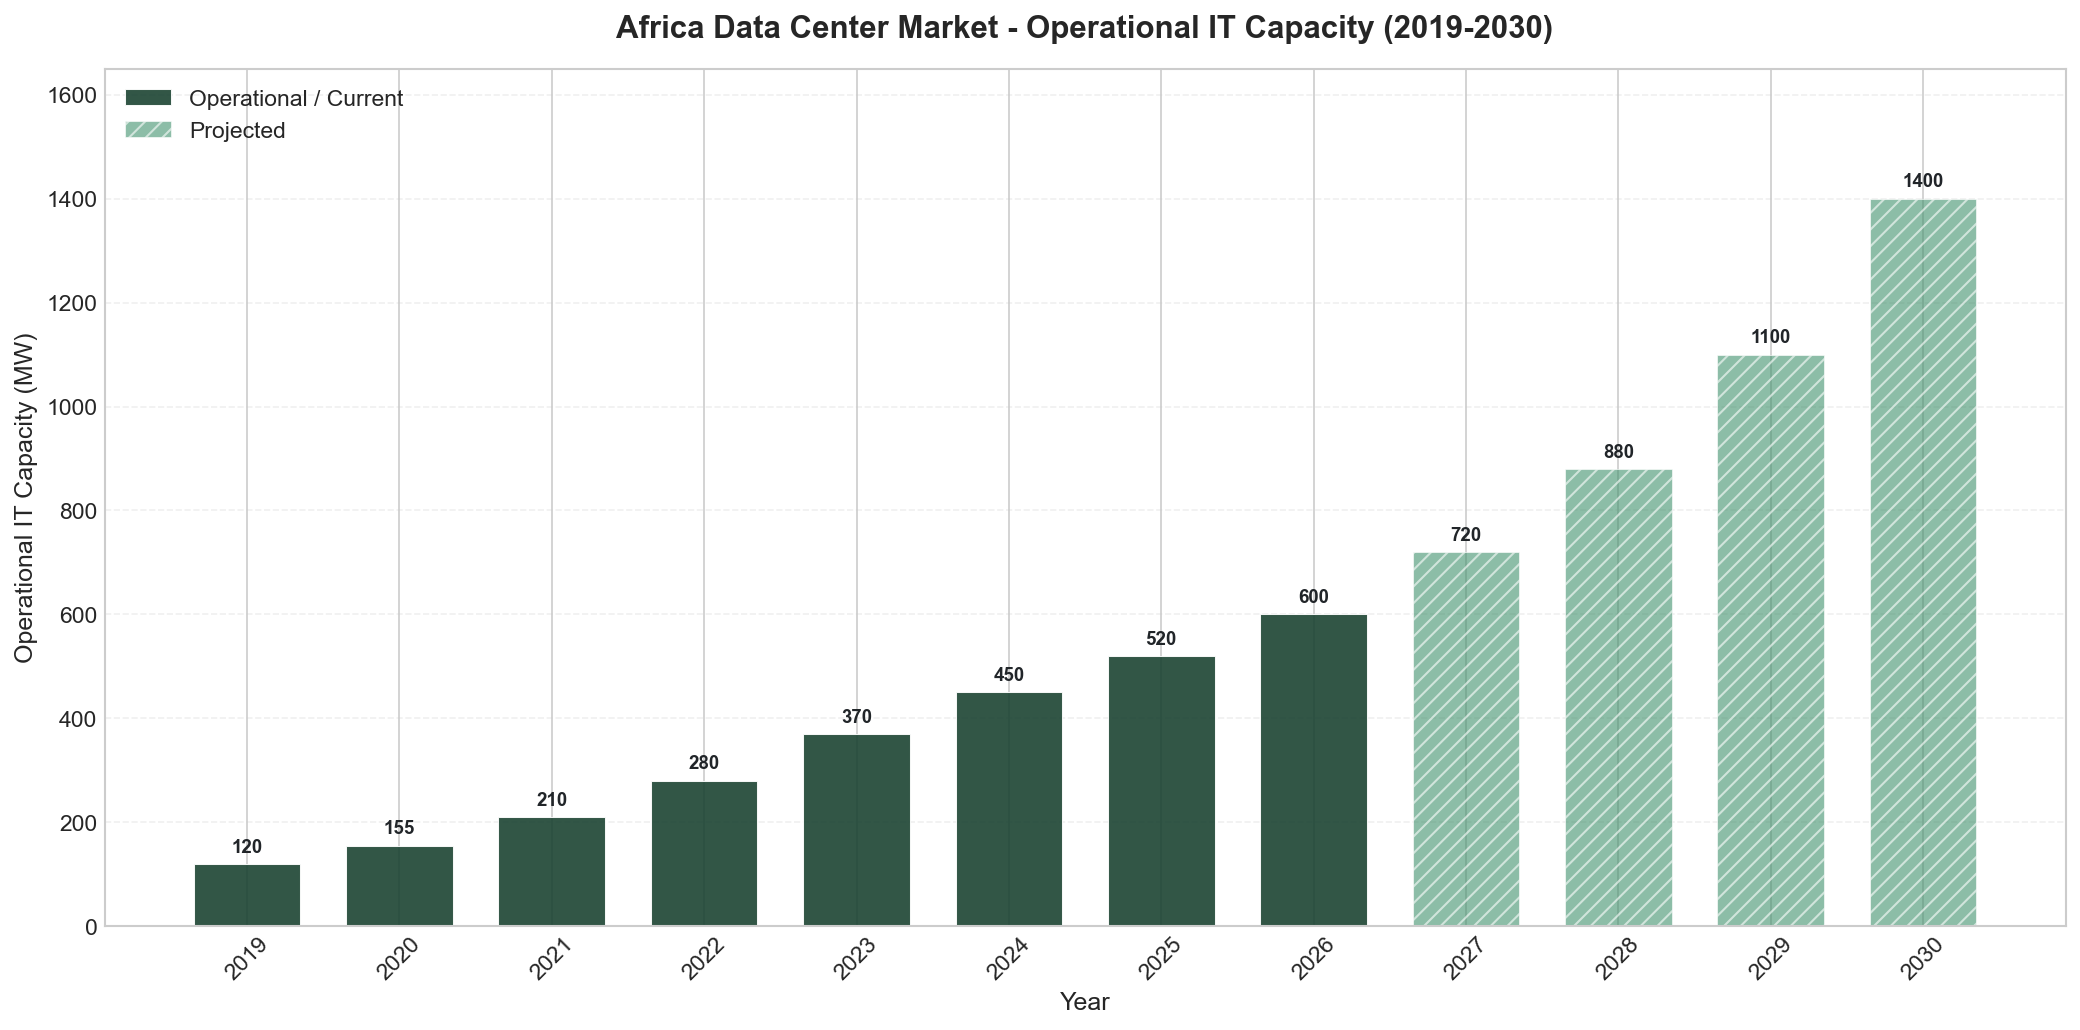

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

actual = africa_dc_capacity[africa_dc_capacity['Type'].isin(['Actual', 'Current'])]
projected = africa_dc_capacity[africa_dc_capacity['Type'] == 'Projected']

bars_actual = ax.bar(actual['Year'], actual['Operational_MW'],
                     color=COLORS['primary'], alpha=0.9, width=0.7,
                     label='Operational / Current', edgecolor='white', linewidth=0.5)
bars_projected = ax.bar(projected['Year'], projected['Operational_MW'],
                        color=COLORS['accent'], alpha=0.6, width=0.7,
                        label='Projected', edgecolor='white', linewidth=0.5,
                        hatch='///')

for bar in list(bars_actual) + list(bars_projected):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 15, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['text'])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Operational IT Capacity (MW)', fontsize=12)
ax.set_title('Africa Data Center Market - Operational IT Capacity (2019-2030)', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(africa_dc_capacity['Year'])
ax.set_xticklabels([str(int(y)) for y in africa_dc_capacity['Year']], rotation=45)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 1650)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/figures/01_africa_dc_capacity_growth.png', dpi=300)
plt.show()


## 1.2 Market by Country

South Africa currently holds the majority of operational capacity. However, Nigeria and Kenya are demonstrating the highest growth rates.
Nigeria presents a strong case for development due to:
- A population exceeding 230 million.
- An internet user base of approximately 110 million active users.
- A regulated domestic gas price of $2.18/MMBtu, offering a significant feedstock cost advantage.


In [5]:
country_data = pd.DataFrame({
    'Country': ['South Africa', 'Nigeria', 'Kenya', 'Egypt',
                'Ghana', 'Morocco', 'Ethiopia', "Côte d'Ivoire",
                'Tanzania', 'Mozambique', 'Others'],
    'Capacity_MW': [360, 80, 45, 35, 20, 15, 12, 8, 6, 4, 15],
    'Growth_Outlook': ['High', 'Very High', 'Very High', 'High',
                       'High', 'Medium', 'Very High', 'Medium',
                       'Medium', 'Medium', 'Medium']
})
country_data['Market_Share'] = (country_data['Capacity_MW'] / country_data['Capacity_MW'].sum() * 100)


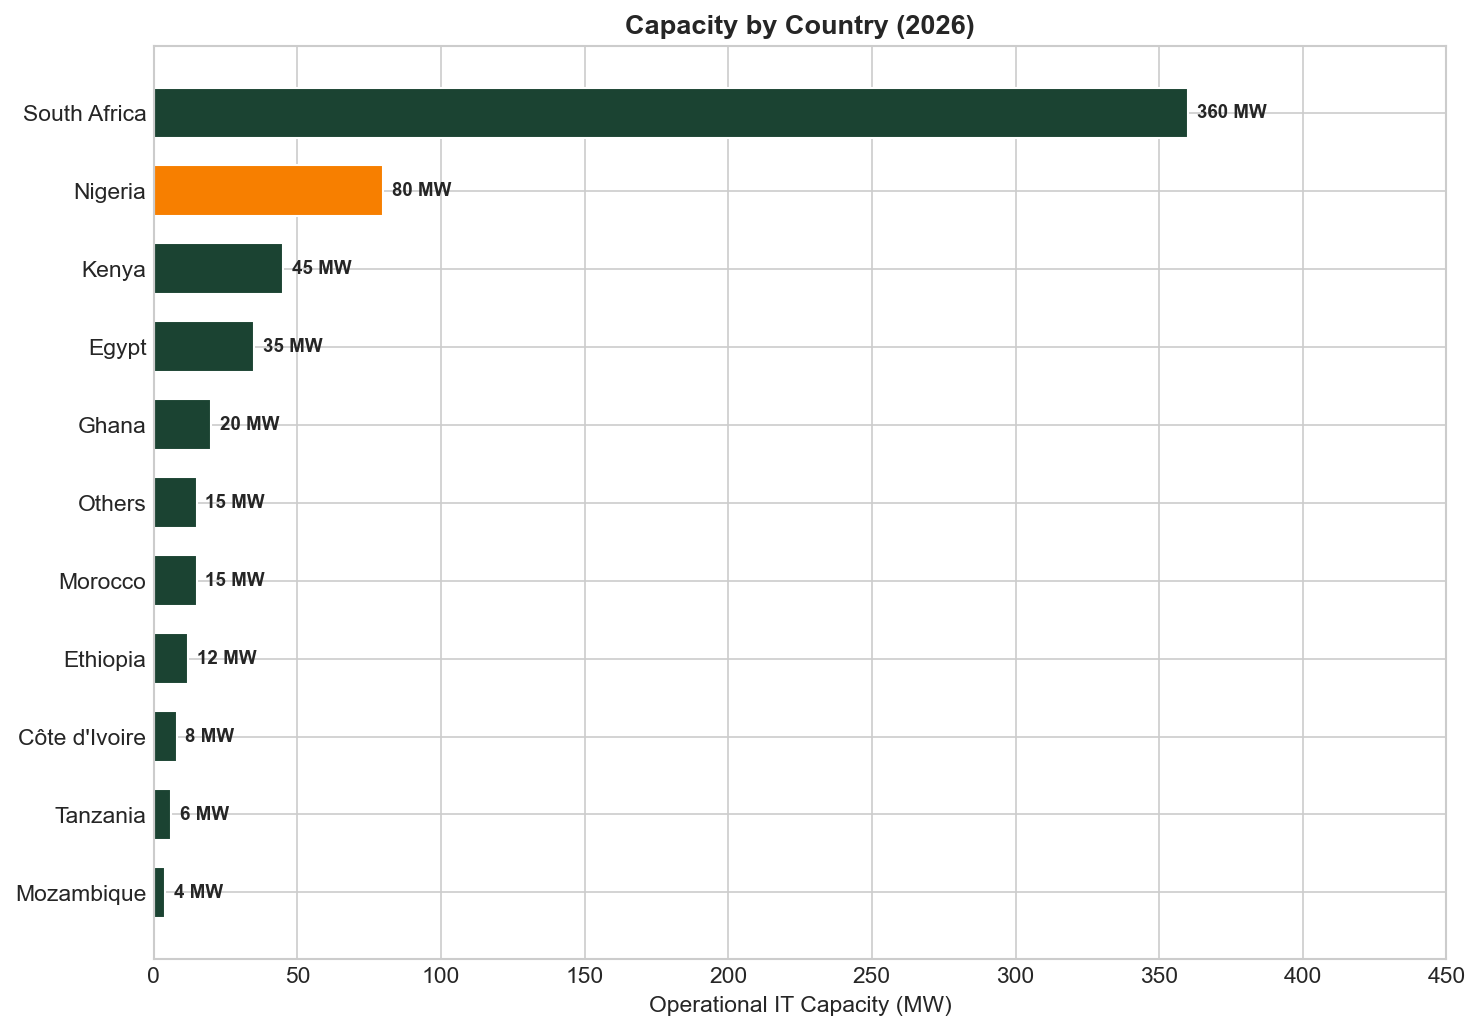

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 7))

sorted_data = country_data.sort_values('Capacity_MW', ascending=True)
colors_bar = [COLORS['highlight'] if c == 'Nigeria' else COLORS['primary'] for c in sorted_data['Country']]

bars = ax1.barh(sorted_data['Country'], sorted_data['Capacity_MW'], color=colors_bar, edgecolor='white', height=0.65)
for bar, val in zip(bars, sorted_data['Capacity_MW']):
    ax1.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f'{int(val)} MW', va='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('Operational IT Capacity (MW)', fontsize=11)
ax1.set_title('Capacity by Country (2026)', fontsize=13, fontweight='bold')
ax1.set_xlim(0, max(sorted_data['Capacity_MW']) * 1.25)

plt.tight_layout()
plt.savefig('../outputs/figures/01_africa_dc_by_country.png', dpi=300)
plt.show()


## 1.3 Submarine Cable Connectivity in Lagos

Lagos functions as a primary digital hub for West Africa, characterized by its high density of submarine cable landings. This infrastructure provides terabits per second of bandwidth and inherent redundancy.

Key cable landing points near the candidate sites:
* **2Africa** (Meta consortium): 180 Tbps capacity, Lekki landing
* **Equiano** (Google): 144 Tbps capacity, Lekki landing
* **MainOne** (Equinix): 10 Tbps capacity, Lekki Phase 1 landing
* **WACS** (MTN/Vodacom): 14.5 Tbps capacity, Lagos landing


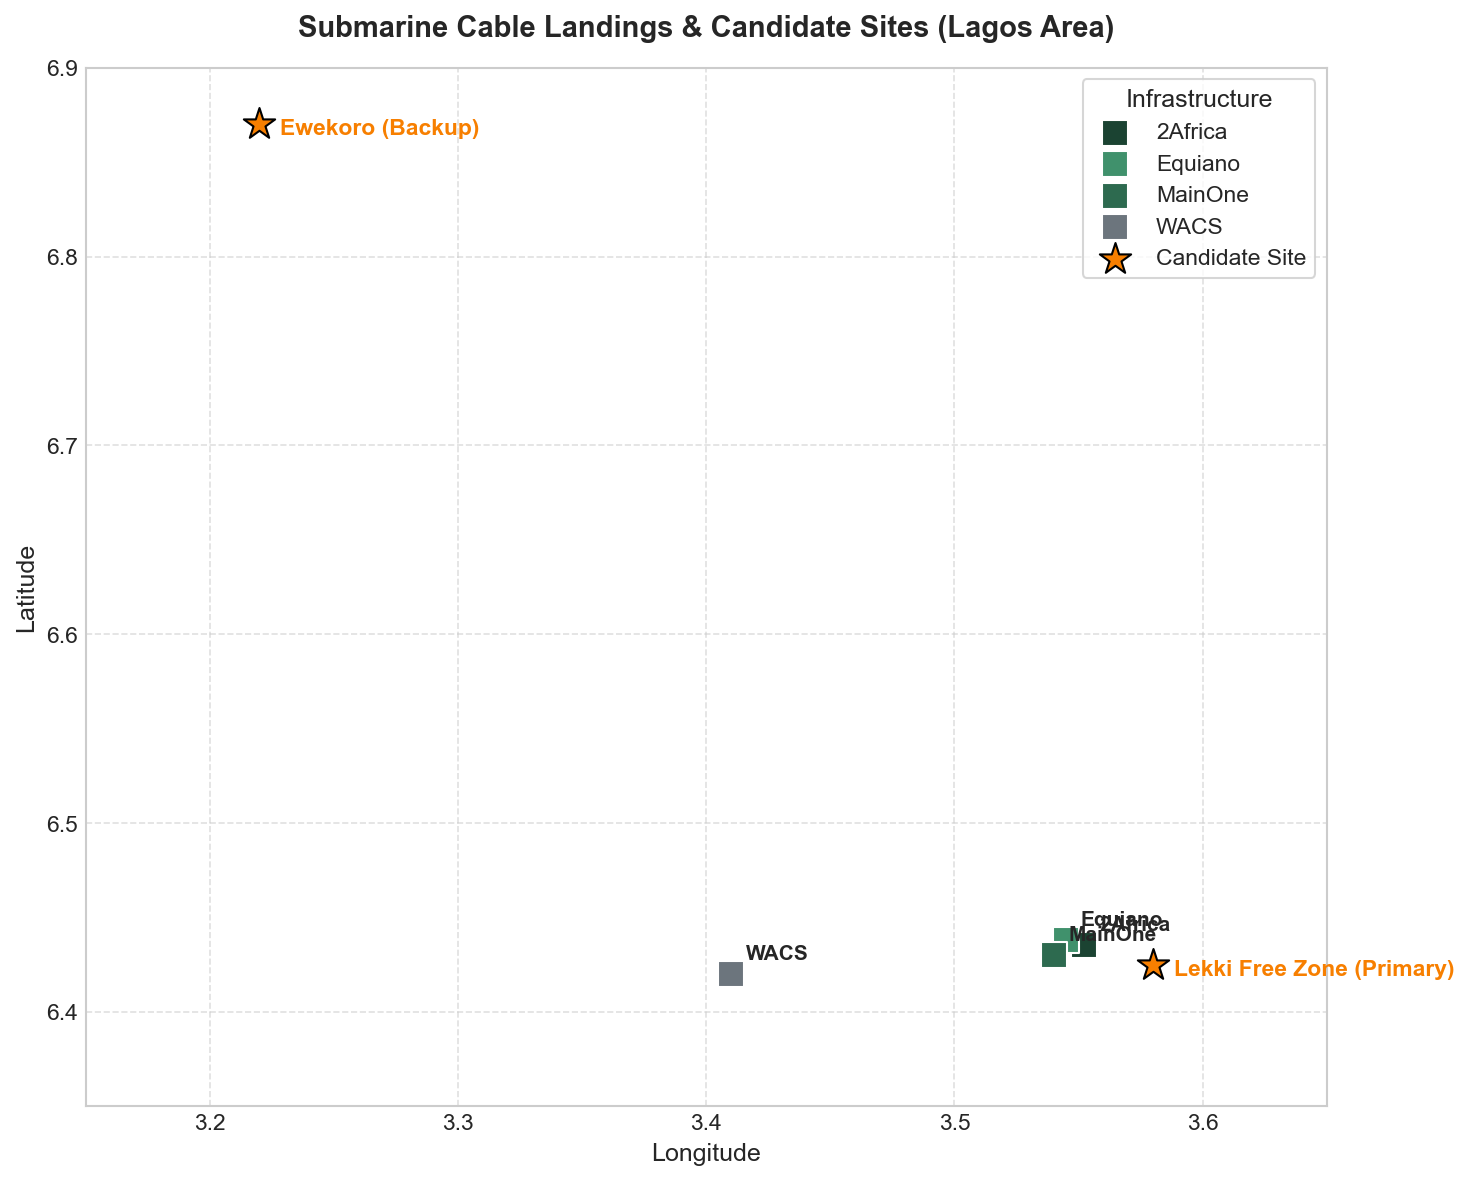

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# Cable Landings
cables = [
    {"name": "2Africa", "lat": 6.4355, "lon": 3.5523, "color": COLORS['primary']},
    {"name": "Equiano", "lat": 6.4380, "lon": 3.5450, "color": COLORS['accent']},
    {"name": "MainOne", "lat": 6.4300, "lon": 3.5400, "color": COLORS['secondary']},
    {"name": "WACS", "lat": 6.4200, "lon": 3.4100, "color": COLORS['neutral']}
]

for c in cables:
    ax.scatter(c['lon'], c['lat'], color=c['color'], s=150, marker='s', edgecolors='white', label=c['name'])
    ax.annotate(c['name'], (c['lon'], c['lat']), xytext=(7, 7), textcoords='offset points', fontweight='bold', fontsize=10)

# Candidate Sites
sites = [
    {"name": "Lekki Free Zone (Primary)", "lat": 6.4250, "lon": 3.5800},
    {"name": "Ewekoro (Backup)", "lat": 6.8700, "lon": 3.2200}
]

for i, s in enumerate(sites):
    label = 'Candidate Site' if i == 0 else "_nolegend_"
    ax.scatter(s['lon'], s['lat'], color=COLORS['highlight'], s=250, marker='*', edgecolors='black', label=label)
    ax.annotate(s['name'], (s['lon'], s['lat']), xytext=(10, -5), textcoords='offset points', fontweight='bold', fontsize=11, color=COLORS['highlight'])

ax.set_title('Submarine Cable Landings & Candidate Sites (Lagos Area)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', title='Infrastructure', title_fontsize=12, frameon=True)

ax.set_xlim(3.15, 3.65)
ax.set_ylim(6.35, 6.90)

plt.tight_layout()
plt.savefig('../outputs/figures/01_lagos_fiber_dc_map_static.png', dpi=300)
plt.show()



## 1.4 Designing the Load Profile

A 15 MW IT load target is selected. This scale aligns with current colocation requirements while supporting an N+1 engine configuration (4 x 4.5 MW units providing 18 MW installed capacity).

The load profile for a colocation data center is modeled as a continuous baseload with minor diurnal fluctuations and a ramp-up curve during the initial operational years.


In [8]:
IT_LOAD_MW = 15.0
PUE_WITH_CCHP = 1.18
PUE_WITHOUT_CCHP = 1.40
HOURS_PER_YEAR = 8760

lagos_monthly_temp = {
    1: 27.5, 2: 28.5, 3: 29.0, 4: 28.5, 5: 27.5, 6: 26.0,
    7: 25.0, 8: 25.0, 9: 25.5, 10: 26.5, 11: 27.5, 12: 27.5
}

np.random.seed(42)
hours = np.arange(HOURS_PER_YEAR)
months = np.array([(h // 720) % 12 + 1 for h in hours])
hour_of_day = hours % 24

diurnal_factor = 1.0 + 0.03 * np.sin(2 * np.pi * (hour_of_day - 6) / 24)
monthly_ramp = np.linspace(0.80, 0.90, 12)
ramp_factor = np.array([monthly_ramp[m-1] for m in months])

it_load = IT_LOAD_MW * ramp_factor * diurnal_factor
it_load += np.random.normal(0, 0.1, HOURS_PER_YEAR)
it_load = np.clip(it_load, IT_LOAD_MW * 0.75, IT_LOAD_MW)


In [9]:
ambient_temps = np.array([lagos_monthly_temp[m] for m in months])
ambient_temps = ambient_temps + 3 * np.sin(2 * np.pi * (hour_of_day - 14) / 24)

cooling_factor = 0.10 + 0.006 * (ambient_temps - 25)
cooling_factor = np.clip(cooling_factor, 0.08, 0.25)

gross_load_cchp = it_load * (1 + cooling_factor)
gross_load_no_cchp = it_load * PUE_WITHOUT_CCHP / 1.0

load_profile = pd.DataFrame({
    'Hour': hours,
    'Month': months,
    'Hour_of_Day': hour_of_day,
    'Ambient_Temp_C': np.round(ambient_temps, 1),
    'IT_Load_MW': np.round(it_load, 3),
    'Cooling_Load_MW': np.round(it_load * cooling_factor, 3),
    'Gross_Load_CCHP_MW': np.round(gross_load_cchp, 3),
    'Gross_Load_NoCCHP_MW': np.round(gross_load_no_cchp, 3),
})

load_profile.to_csv('../data/section_01_load_profile.csv', index=False)


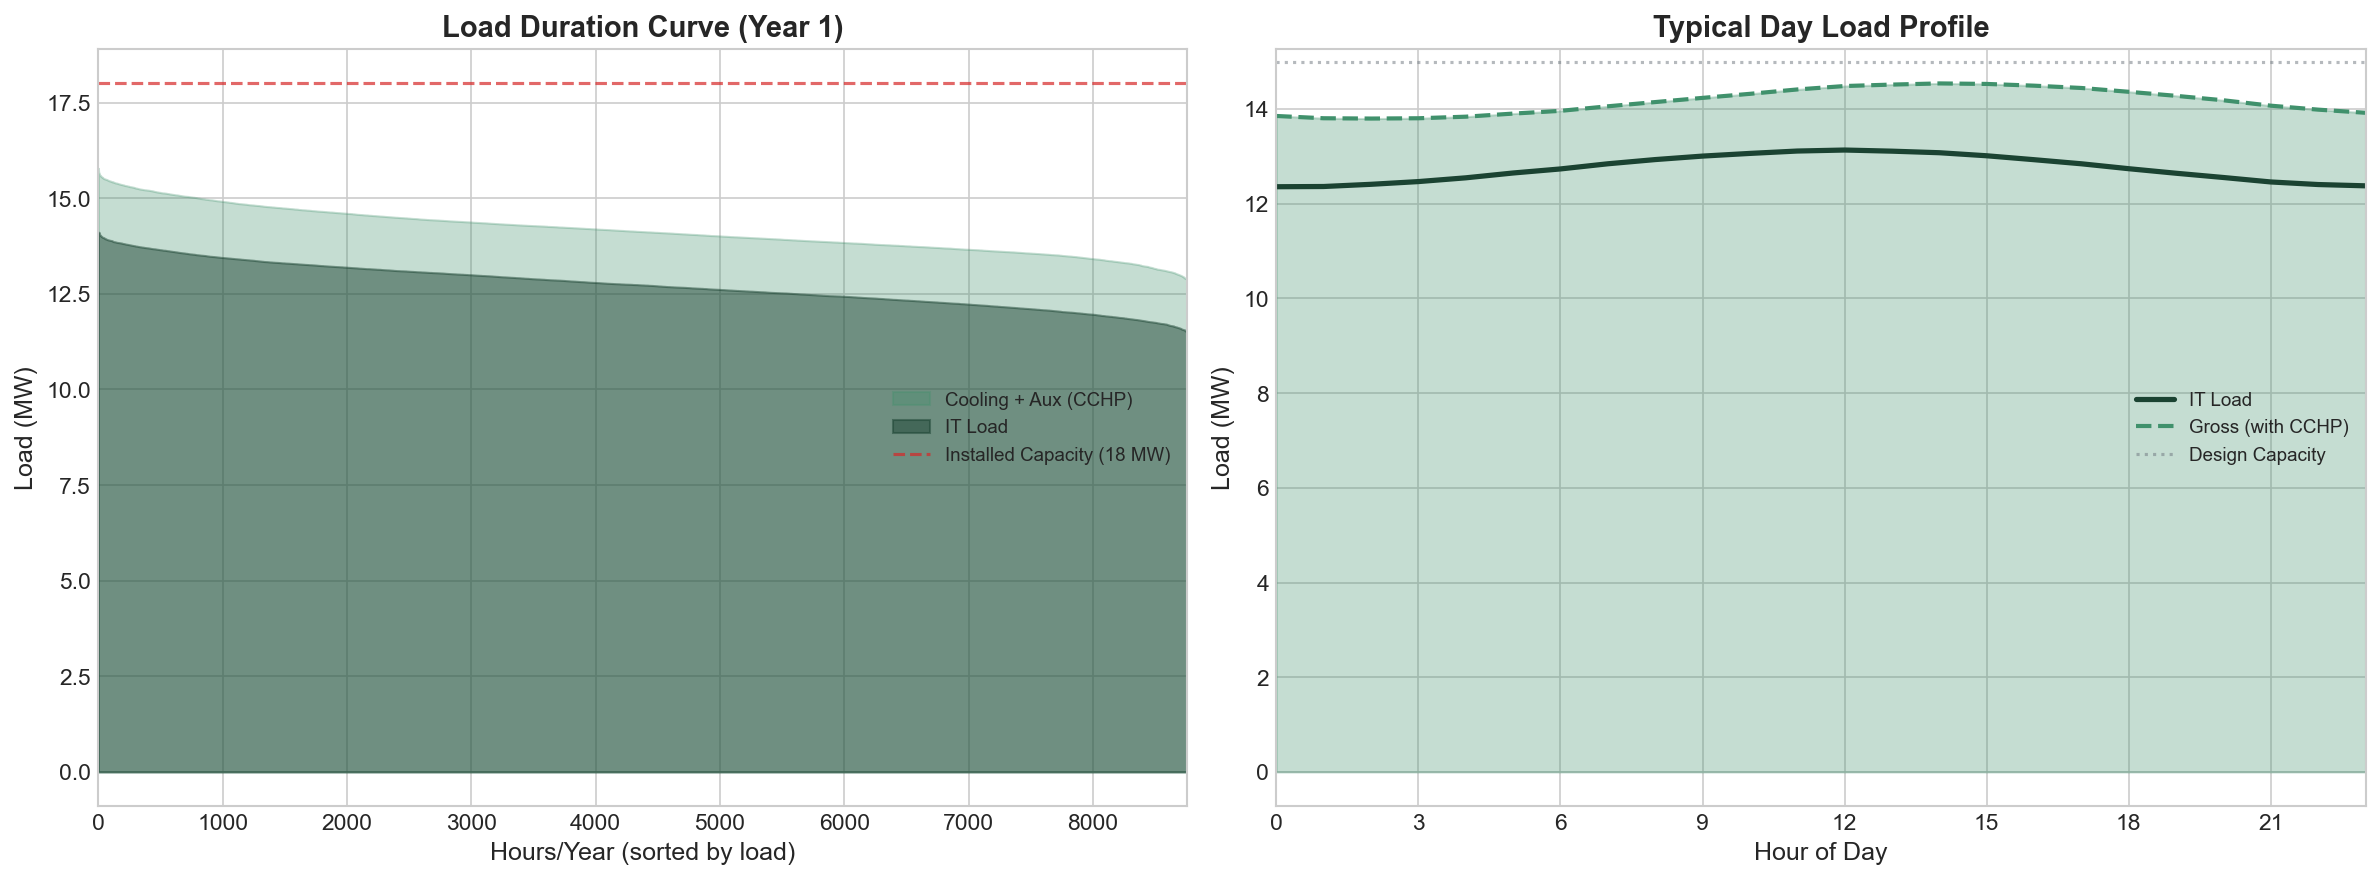

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sorted_it = np.sort(load_profile['IT_Load_MW'].values)[::-1]
sorted_gross = np.sort(load_profile['Gross_Load_CCHP_MW'].values)[::-1]
hours_axis = np.arange(1, HOURS_PER_YEAR + 1)

ax.fill_between(hours_axis, sorted_gross, alpha=0.3, color=COLORS['accent'], label='Cooling + Aux (CCHP)')
ax.fill_between(hours_axis, sorted_it, alpha=0.5, color=COLORS['primary'], label='IT Load')
ax.axhline(y=18, color=COLORS['warning'], linestyle='--', alpha=0.7, label='Installed Capacity (18 MW)')
ax.set_xlabel('Hours/Year (sorted by load)')
ax.set_ylabel('Load (MW)')
ax.set_title('Load Duration Curve (Year 1)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, HOURS_PER_YEAR)

ax = axes[1]
hourly_avg = load_profile.groupby('Hour_of_Day').agg({'IT_Load_MW': 'mean', 'Gross_Load_CCHP_MW': 'mean'}).reset_index()

ax.fill_between(hourly_avg['Hour_of_Day'], hourly_avg['Gross_Load_CCHP_MW'], alpha=0.3, color=COLORS['accent'])
ax.plot(hourly_avg['Hour_of_Day'], hourly_avg['IT_Load_MW'], linewidth=2.5, color=COLORS['primary'], label='IT Load')
ax.plot(hourly_avg['Hour_of_Day'], hourly_avg['Gross_Load_CCHP_MW'], linewidth=2, color=COLORS['accent'], linestyle='--', label='Gross (with CCHP)')
ax.axhline(y=IT_LOAD_MW, color=COLORS['neutral'], linestyle=':', alpha=0.5, label='Design Capacity')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Load (MW)')
ax.set_title('Typical Day Load Profile', fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=9)
ax.set_xlim(0, 23)

plt.tight_layout()
plt.savefig('../outputs/figures/01_load_profile_analysis.png', dpi=300)
plt.show()


In [11]:
ramp_years = pd.DataFrame({
    'Year': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Avg_IT_Utilization': [0.85, 0.90, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]
})

ramp_years['IT_Load_MW'] = IT_LOAD_MW * ramp_years['Avg_IT_Utilization']
ramp_years['Gross_Load_MW'] = ramp_years['IT_Load_MW'] * PUE_WITH_CCHP
ramp_years['Annual_Generation_MWh'] = ramp_years['Gross_Load_MW'] * HOURS_PER_YEAR
ramp_years['Capacity_Factor'] = ramp_years['Gross_Load_MW'] / 18.0

ramp_years.to_csv('../data/section_01_ramp_projection.csv', index=False)


## 1.5 Value Proposition

The concept addresses key challenges in the regional data center market:
1. **Cost Efficiency**: Establishing power access at approximately $0.016/kWh fuel cost, significantly below the $0.25-0.35/kWh diesel baseline.
2. **Reliability**: A Tier III design (99.982% uptime) supported by N+1 reciprocating gas engines and local gas infrastructure.
3. **Cooling Optimization**: Targeted PUE of 1.18 through combined cooling, heat, and power (CCHP) technology.


In [12]:
market_summary = {
    'design_parameters': {
        'it_load_mw': 15.0,
        'pue_with_cchp': 1.18,
        'pue_without_cchp': 1.40,
        'installed_capacity_mw': 18.0,
        'target_tier': 'Tier III (99.982% availability)'
    },
    'market_context': {
        'africa_dc_capacity_2026_mw': 600,
        'africa_dc_capacity_2030_mw': 1400,
        'nigeria_internet_users_m': 110,
        'nigeria_population_m': 230
    },
    'gas_economics': {
        'nigeria_regulated_price_usd_mmbtu': 2.18,
        'diesel_comparison_usd_kwh': 0.30
    }
}

with open('../data/section_01_market_summary.json', 'w') as f:
    json.dump(market_summary, f, indent=2)
